In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [6]:
import joblib

In [ ]:
df = pd.read_excel(
    "data/employee_burnout_prediction_500_rows.xlsx"
)

In [ ]:
df.head()

,Employee_ID,Age,Department,Job_Role,Employment_Status,Years_of_Experience,Work_Hours_Per_Week,Overtime,Workload,Number_of_Projects,...,Sleep_Quality,Stress_Level,Remote_Work,Screen_Time_Hours,Physical_Activity_Hours,Exercise_Frequency,Support_System,Absenteeism_Days,Productivity_Score,Burnout_Risk
0,EMP0001,49,IT,Accountant,Full-time,15,40.7,No,High,4,...,Average,Medium,No,7.6,6.5,Never,Moderate,3,60.3,High
1,EMP0002,35,Marketing,Data Analyst,Full-time,15,45.5,No,Medium,1,...,Good,Medium,No,6.8,0.0,Often,Moderate,2,65.7,High
2,EMP0003,28,IT,Accountant,Full-time,7,40.7,No,Low,6,...,Poor,Low,No,5.7,4.0,Rarely,Moderate,3,65.3,High
3,EMP0004,41,Operations,HR Executive,Full-time,6,40.1,No,Medium,4,...,Average,Low,No,7.4,2.3,Sometimes,Weak,5,78.8,High
4,EMP0005,39,HR,Software Engineer,Full-time,5,37.7,No,Medium,5,...,Poor,Medium,No,9.2,3.8,Rarely,Weak,5,64.6,High


In [ ]:
df.shape

(500, 23)

In [ ]:
df.columns

Index(['Employee_ID', 'Age', 'Department', 'Job_Role', 'Employment_Status',
       'Years_of_Experience', 'Work_Hours_Per_Week', 'Overtime', 'Workload',
       'Number_of_Projects', 'Job_Satisfaction', 'Work_Life_Balance',
       'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Remote_Work',
       'Screen_Time_Hours', 'Physical_Activity_Hours', 'Exercise_Frequency',
       'Support_System', 'Absenteeism_Days', 'Productivity_Score',
       'Burnout_Risk'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              500 non-null    str    
 1   Age                      500 non-null    int64  
 2   Department               500 non-null    str    
 3   Job_Role                 500 non-null    str    
 4   Employment_Status        500 non-null    str    
 5   Years_of_Experience      500 non-null    int64  
 6   Work_Hours_Per_Week      500 non-null    float64
 7   Overtime                 500 non-null    str    
 8   Workload                 500 non-null    str    
 9   Number_of_Projects       500 non-null    int64  
 10  Job_Satisfaction         500 non-null    int64  
 11  Work_Life_Balance        500 non-null    int64  
 12  Sleep_Hours              500 non-null    float64
 13  Sleep_Quality            500 non-null    str    
 14  Stress_Level             500 non-null

In [ ]:
df.isnull().sum()

Employee_ID                0
Age                        0
Department                 0
Job_Role                   0
Employment_Status          0
Years_of_Experience        0
Work_Hours_Per_Week        0
Overtime                   0
Workload                   0
Number_of_Projects         0
Job_Satisfaction           0
Work_Life_Balance          0
Sleep_Hours                0
Sleep_Quality              0
Stress_Level               0
Remote_Work                0
Screen_Time_Hours          0
Physical_Activity_Hours    0
Exercise_Frequency         0
Support_System             0
Absenteeism_Days           0
Productivity_Score         0
Burnout_Risk               0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Burnout_Risk"].value_counts()

Burnout_Risk
High        461
Moderate     39
Name: count, dtype: int64

In [ ]:
"""Employee information
        ↓
       X
        ↓
    ML Model
        ↓
       Y
        ↓
Burnout_Risk"""

'Employee information\n        ↓\n       X\n        ↓\n    ML Model\n        ↓\n       Y\n        ↓\nBurnout_Risk'

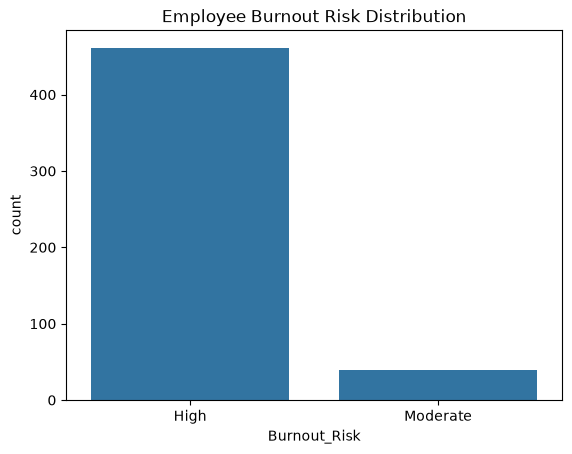

In [ ]:
sns.countplot(data=df, x="Burnout_Risk")
plt.title("Employee Burnout Risk Distribution")
plt.show()

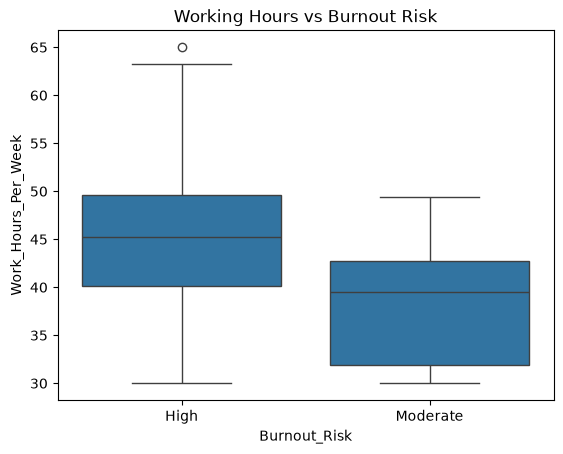

In [ ]:
sns.boxplot(
    data=df,
    x="Burnout_Risk",
    y="Work_Hours_Per_Week"
)

plt.title("Working Hours vs Burnout Risk")
plt.show()

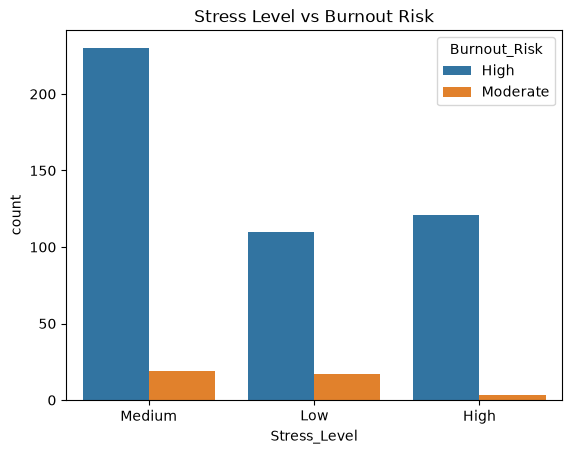

In [ ]:
sns.countplot(
    data=df,
    x="Stress_Level",
    hue="Burnout_Risk"
)

plt.title("Stress Level vs Burnout Risk")
plt.show()

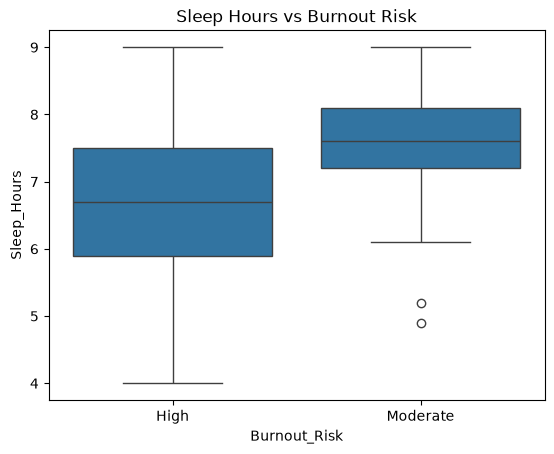

In [ ]:
sns.boxplot(
    data=df,
    x="Burnout_Risk",
    y="Sleep_Hours"
)

plt.title("Sleep Hours vs Burnout Risk")
plt.show()

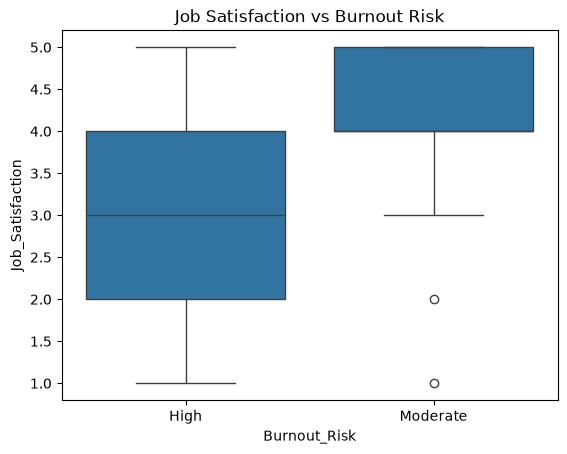

In [ ]:
sns.boxplot(
    data=df,
    x="Burnout_Risk",
    y="Job_Satisfaction"
)

plt.title("Job Satisfaction vs Burnout Risk")
plt.show()

In [ ]:
df_ml = df.drop("Employee_ID", axis=1)

In [ ]:
X = df_ml.drop("Burnout_Risk", axis=1)

y = df_ml["Burnout_Risk"]

In [ ]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_9460\608454331.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [ ]:
print("Categorical:", list(categorical_columns))
print("Numerical:", list(numerical_columns))

Categorical: ['Department', 'Job_Role', 'Employment_Status', 'Overtime', 'Workload', 'Sleep_Quality', 'Stress_Level', 'Remote_Work', 'Exercise_Frequency', 'Support_System']
Numerical: ['Age', 'Years_of_Experience', 'Work_Hours_Per_Week', 'Number_of_Projects', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Absenteeism_Days', 'Productivity_Score']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numerical_columns
        )
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

In [ ]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['High','Moderate']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Age','Department','Job_Role',...,'Support_System','Absenteeism_Days', 'Productivity_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [ ]:
y_pred = logistic_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.94


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

        High       0.99      0.95      0.97        92
    Moderate       0.58      0.88      0.70         8

    accuracy                           0.94       100
   macro avg       0.79      0.91      0.83       100
weighted avg       0.96      0.94      0.95       100



In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [ ]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['High','Moderate']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Age','Department','Job_Role',...,'Support_System','Absenteeism_Days', 'Productivity_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.91


In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

        High       0.92      0.99      0.95        92
    Moderate       0.00      0.00      0.00         8

    accuracy                           0.91       100
   macro avg       0.46      0.49      0.48       100
weighted avg       0.85      0.91      0.88       100



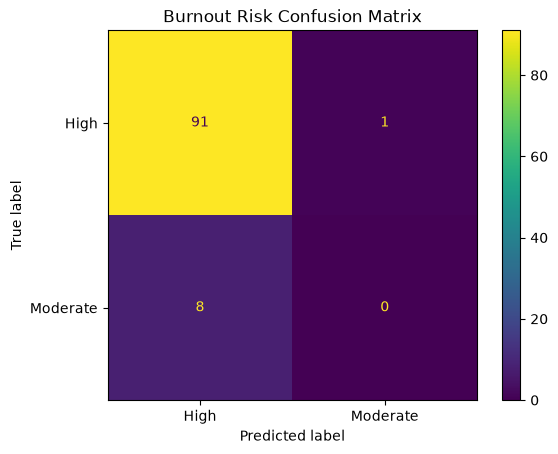

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Burnout Risk Confusion Matrix")
plt.show()

In [ ]:
import joblib

joblib.dump(
    rf_model,
    "models/burnout_model.pkl"
)

['models/burnout_model.pkl']

In [ ]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_excel("data/employee_burnout_prediction_500_rows.xlsx")

df.head()

,Employee_ID,Age,Department,Job_Role,Employment_Status,Years_of_Experience,Work_Hours_Per_Week,Overtime,Workload,Number_of_Projects,...,Sleep_Quality,Stress_Level,Remote_Work,Screen_Time_Hours,Physical_Activity_Hours,Exercise_Frequency,Support_System,Absenteeism_Days,Productivity_Score,Burnout_Risk
0,EMP0001,49,IT,Accountant,Full-time,15,40.7,No,High,4,...,Average,Medium,No,7.6,6.5,Never,Moderate,3,60.3,High
1,EMP0002,35,Marketing,Data Analyst,Full-time,15,45.5,No,Medium,1,...,Good,Medium,No,6.8,0.0,Often,Moderate,2,65.7,High
2,EMP0003,28,IT,Accountant,Full-time,7,40.7,No,Low,6,...,Poor,Low,No,5.7,4.0,Rarely,Moderate,3,65.3,High
3,EMP0004,41,Operations,HR Executive,Full-time,6,40.1,No,Medium,4,...,Average,Low,No,7.4,2.3,Sometimes,Weak,5,78.8,High
4,EMP0005,39,HR,Software Engineer,Full-time,5,37.7,No,Medium,5,...,Poor,Medium,No,9.2,3.8,Rarely,Weak,5,64.6,High


In [ ]:
X = df.drop(columns=["Employee_ID", "Burnout_Risk"])

y = df["Burnout_Risk"]

In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

numeric_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numeric_columns)

Categorical columns: ['Department', 'Job_Role', 'Employment_Status', 'Overtime', 'Workload', 'Sleep_Quality', 'Stress_Level', 'Remote_Work', 'Exercise_Frequency', 'Support_System']
Numerical columns: ['Age', 'Years_of_Experience', 'Work_Hours_Per_Week', 'Number_of_Projects', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Absenteeism_Days', 'Productivity_Score']


C:\Users\DELL\AppData\Local\Temp\ipykernel_9460\867085814.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numeric_columns
        )
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [ ]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['High','Moderate']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Age','Department','Job_Role',...,'Support_System','Absenteeism_Days', 'Productivity_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'

In [ ]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

        High       0.92      1.00      0.96        92
    Moderate       0.00      0.00      0.00         8

    accuracy                           0.92       100
   macro avg       0.46      0.50      0.48       100
weighted avg       0.85      0.92      0.88       100



c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [ ]:
joblib.dump(
    rf_model,
    "models/burnout_model.pkl"
)

['models/burnout_model.pkl']

In [ ]:
print("classes:", rf_model.classes_)

classes: ['High' 'Moderate']


In [ ]:
print(y.value_counts())

Burnout_Risk
High        461
Moderate     39
Name: count, dtype: int64


In [ ]:
# Create a burnout score from workplace factors

score = (
    (df["Work_Hours_Per_Week"] > 45).astype(int) +
    (df["Work_Hours_Per_Week"] > 50).astype(int) +
    (df["Overtime"] == "Yes").astype(int) +
    (df["Workload"] == "Medium").astype(int) +
    2 * (df["Workload"] == "High").astype(int) +
    (df["Job_Satisfaction"] <= 3).astype(int) +
    (df["Job_Satisfaction"] <= 2).astype(int) +
    (df["Work_Life_Balance"] <= 3).astype(int) +
    (df["Work_Life_Balance"] <= 2).astype(int) +
    (df["Sleep_Hours"] < 7).astype(int) +
    (df["Sleep_Hours"] < 6).astype(int) +
    (df["Stress_Level"] == "Medium").astype(int) +
    2 * (df["Stress_Level"] == "High").astype(int) +
    (df["Absenteeism_Days"] >= 4).astype(int) +
    (df["Absenteeism_Days"] >= 8).astype(int)
)

df["Burnout_Score_Calculated"] = score

df["Burnout_Risk"] = pd.qcut(
    df["Burnout_Score_Calculated"],
    q=3,
    labels=["Low", "Moderate", "High"],
    duplicates="drop"
)

print(df["Burnout_Risk"].value_counts())

Burnout_Risk
Low         187
Moderate    171
High        142
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=[
    "Employee_ID",
    "Burnout_Risk",
    "Burnout_Score_Calculated"
])

y = df["Burnout_Risk"]

print(X.shape)
print(y.value_counts())

(500, 21)
Burnout_Risk
Low         187
Moderate    171
High        142
Name: count, dtype: int64


In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

numeric_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_columns)
print("Numeric:", numeric_columns)

Categorical: ['Department', 'Job_Role', 'Employment_Status', 'Overtime', 'Workload', 'Sleep_Quality', 'Stress_Level', 'Remote_Work', 'Exercise_Frequency', 'Support_System']
Numeric: ['Age', 'Years_of_Experience', 'Work_Hours_Per_Week', 'Number_of_Projects', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Screen_Time_Hours', 'Physical_Activity_Hours', 'Absenteeism_Days', 'Productivity_Score']


C:\Users\DELL\AppData\Local\Temp\ipykernel_9460\844150479.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", "passthrough", numeric_columns)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Moderate']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Age','Department','Job_Role',...,'Support_System','Absenteeism_Days', 'Productivity_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.76
              precision    recall  f1-score   support

        High       0.78      0.86      0.82        29
         Low       0.83      0.81      0.82        37
    Moderate       0.66      0.62      0.64        34

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100



In [ ]:
print("Classes:", rf_model.classes_)

Classes: ['High' 'Low' 'Moderate']


In [ ]:
import joblib

joblib.dump(
    rf_model,
    "models/burnout_model.pkl"
)

['models/burnout_model.pkl']